In [13]:
import pandas as pd

df = pd.DataFrame({
    "Transmission": ["Automatic", "Manual", "Automatic", "Manual"],
    "Color": ["Red", "Blue", "Green", "Red"]
})

print(df)


  Transmission  Color
0    Automatic    Red
1       Manual   Blue
2    Automatic  Green
3       Manual    Red


In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Transmission"] = le.fit_transform(df["Transmission"])

print(df)


   Transmission  Color
0             0    Red
1             1   Blue
2             0  Green
3             1    Red


In [15]:
df = pd.get_dummies(df, columns=["Color"], drop_first=True)

print(df)


   Transmission  Color_Green  Color_Red
0             0        False       True
1             1        False      False
2             0         True      False
3             1        False       True


In [17]:
print(df.columns)


Index(['Transmission', 'Color_Green', 'Color_Red'], dtype='object')


In [21]:
df = pd.get_dummies(df, columns=["Color_Red"], drop_first=True)

print(df)


   Transmission  Color_Green  Color_Red_True
0             0        False            True
1             1        False           False
2             0         True           False
3             1        False            True


In [22]:
import pandas as pd

df = pd.DataFrame({
    "Age": [22, 25, 30, 35, 40],
    "Salary": [25000, 30000, 50000, 70000, 90000]
})

print(df)


   Age  Salary
0   22   25000
1   25   30000
2   30   50000
3   35   70000
4   40   90000


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

print(df_standardized)


        Age    Salary
0 -1.286384 -1.146925
1 -0.826961 -0.942117
2 -0.061256 -0.122885
3  0.704448  0.696347
4  1.470153  1.515579


In [24]:
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()
df_normalized = pd.DataFrame(
    mm.fit_transform(df),
    columns=df.columns
)

print(df_normalized)


        Age    Salary
0  0.000000  0.000000
1  0.166667  0.076923
2  0.444444  0.384615
3  0.722222  0.692308
4  1.000000  1.000000


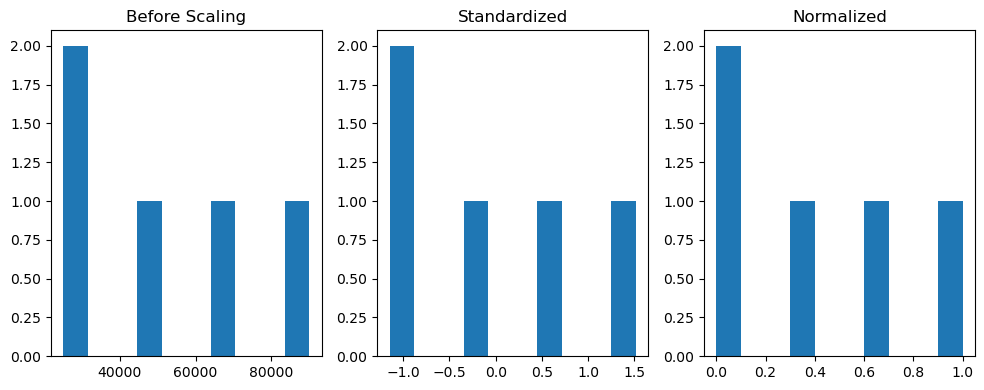

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Before scaling
plt.subplot(1,3,1)
plt.hist(df["Salary"])
plt.title("Before Scaling")

# After Standardization
plt.subplot(1,3,2)
plt.hist(df_standardized["Salary"])
plt.title("Standardized")

# After Normalization
plt.subplot(1,3,3)
plt.hist(df_normalized["Salary"])
plt.title("Normalized")

plt.tight_layout()
plt.show()


In [26]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# reproducibility
np.random.seed(0)

# X has a curved relationship with y
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = 3*X**2 + 2*X + np.random.randn(100, 1) * 2  # quadratic + noise

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [27]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_linear = lin_reg.predict(X_test)
r2_linear = r2_score(y_test, y_pred_linear)
print("R² (Linear):", r2_linear)


R² (Linear): -0.060939285858313985


In [28]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly, y, test_size=0.2
)


In [29]:
lin_reg_poly = LinearRegression()
lin_reg_poly.fit(X_train_p, y_train_p)

y_pred_poly = lin_reg_poly.predict(X_test_p)
r2_poly = r2_score(y_test_p, y_pred_poly)
print("R² (Polynomial):", r2_poly)


R² (Polynomial): 0.9787496689624068
